In [1]:
# ============================================
# MANUAL K-MEANS IMPLEMENTATION (SMALL DATASET)
# ============================================

import numpy as np

# Small dataset
X = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [3.0, 4.0],
    [5.0, 7.0],
    [3.5, 5.0],
    [4.5, 5.0],
    [3.5, 4.5]
])

k = 2  # number of clusters

# Step 1: Initialize centroids randomly
centroids = X[np.random.choice(range(len(X)), k, replace=False)]
print("Initial Centroids:\n", centroids)

for iteration in range(10):  # limit to 10 iterations
    # Step 2: Assign points to nearest centroid
    distances = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
    labels = np.argmin(distances, axis=1)

    # Step 3: Update centroids
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
    
    print(f"\nIteration {iteration + 1}")
    print("Labels:", labels)
    print("Updated Centroids:\n", new_centroids)

    # Step 4: Check for convergence
    if np.allclose(centroids, new_centroids):
        print("\nConverged!")
        break
    centroids = new_centroids

print("\nFinal Centroids:\n", centroids)
print("Final Labels:", labels)


Initial Centroids:
 [[5.  7. ]
 [3.5 4.5]]

Iteration 1
Labels: [1 1 1 0 1 1 1]
Updated Centroids:
 [[5.         7.        ]
 [2.83333333 3.58333333]]

Iteration 2
Labels: [1 1 1 0 1 0 1]
Updated Centroids:
 [[4.75 6.  ]
 [2.5  3.3 ]]

Iteration 3
Labels: [1 1 1 0 0 0 1]
Updated Centroids:
 [[4.33333333 5.66666667]
 [2.25       2.875     ]]

Iteration 4
Labels: [1 1 1 0 0 0 0]
Updated Centroids:
 [[4.125      5.375     ]
 [1.83333333 2.33333333]]

Iteration 5
Labels: [1 1 0 0 0 0 0]
Updated Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]

Iteration 6
Labels: [1 1 0 0 0 0 0]
Updated Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]

Converged!

Final Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]
Final Labels: [1 1 0 0 0 0 0]


Cluster Centers:
 [[2.41458584 7.69772368]
 [4.76764846 2.46202826]
 [7.64632341 6.43617795]]
Labels: [0 1 1 1 2 0 1 1 0 0 2 0 0 1 2 1 2 0 0 1 0 1 1 2 1 2 2 1 2 2 0 1 1 0 2 2 2
 0 2 2 0 2 0 1 1 0 1 0 1 1 2 2 0 1 1 0 1 1 0 0 1 0 2 2 0 1 1 1 2 1 1 0 1 2
 1 0 2 1 2 1 0 1 1 2 2 1 2 0 2 1 1 1 1 0 2 1 2 0 1 1]


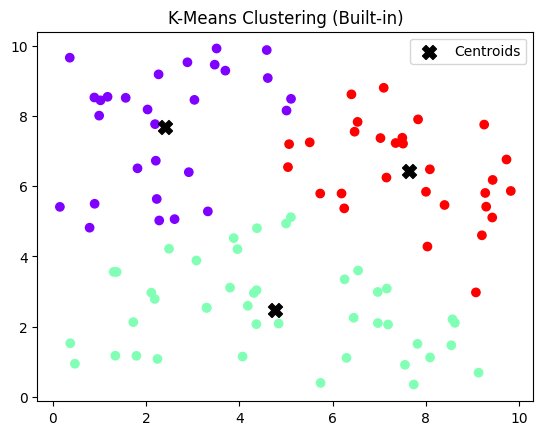

In [2]:
# ============================================
# BUILT-IN K-MEANS USING SCIKIT-LEARN
# ============================================

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Large dataset (randomly generated)
X_large = np.random.rand(100, 2) * 10

# Define and train K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_large)

# Display results
print("Cluster Centers:\n", kmeans.cluster_centers_)
print("Labels:", kmeans.labels_)

# Visualization
plt.scatter(X_large[:, 0], X_large[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=100, label='Centroids')
plt.title("K-Means Clustering (Built-in)")
plt.legend()
plt.show()


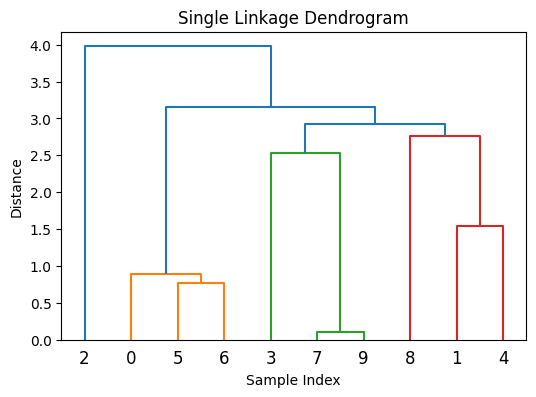

Cluster Labels: [1 1 1 1 1 1 1 1 1 1]


In [3]:
# ============================================
# BUILT-IN SINGLE LINKAGE USING SCIPY
# ============================================

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np

# Large dataset (randomly generated)
X_large = np.random.rand(10, 2) * 10

# Perform single linkage hierarchical clustering
Z = linkage(X_large, method='single')

# Display dendrogram
plt.figure(figsize=(6, 4))
dendrogram(Z)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# Cut dendrogram at distance threshold
threshold = 5.0
clusters = fcluster(Z, t=threshold, criterion='distance')
print("Cluster Labels:", clusters)
